# **Project Name** **- Mind at Work: A Data-Driven Look at Mental Health in the Tech Industry**

##### **Project Type** - EDA
##### **Contribution** - Individual
##### **Team Member 1 -** Vipsa Patel

# **GitHub Link -**

# **Problem Statement**

Attitudes toward mental health in the tech workplace vary widely, and it isn't clear which specific factors — employer support, company size, demographics, or workplace culture — actually drive whether an employee seeks treatment. Without knowing what matters, companies risk investing in the wrong interventions.

#### **Define Your Business Objective?**

To analyze the workplace factors that affect an employee's mental health, and to assess how many people seek treatment and how well workplaces support mental health, using the 2014 OSMI Mental Health in Tech Survey.

**Section 1: Know Your Data**
### Import Libraries

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from wordcloud import WordCloud

# Plot styling
sns.set_style("whitegrid")
plt.rcParams['figure.figsize'] = (10, 5)
pd.set_option('display.max_columns', None)

**### Dataset Loading**

In [2]:
df = pd.read_csv('https://raw.githubusercontent.com/Vipsa2207/Mental-Health-In-Tech/refs/heads/main/survey.csv')

**### Dataset First View**

In [3]:
df = pd.read_csv('survey.csv')
df.head()

,Timestamp,Age,Gender,Country,state,self_employed,family_history,treatment,work_interfere,no_employees,remote_work,tech_company,benefits,care_options,wellness_program,seek_help,anonymity,leave,mental_health_consequence,phys_health_consequence,coworkers,supervisor,mental_health_interview,phys_health_interview,mental_vs_physical,obs_consequence,comments
0,2014-08-27 11:29:31,37,Female,United States,IL,NaN,No,Yes,Often,6-25,No,Yes,Yes,Not sure,No,Yes,Yes,Somewhat easy,No,No,Some of them,Yes,No,Maybe,Yes,No,NaN
1,2014-08-27 11:29:37,44,M,United States,IN,NaN,No,No,Rarely,More than 1000,No,No,Don't know,No,Don't know,Don't know,Don't know,Don't know,Maybe,No,No,No,No,No,Don't know,No,NaN
2,2014-08-27 11:29:44,32,Male,Canada,NaN,NaN,No,No,Rarely,6-25,No,Yes,No,No,No,No,Don't know,Somewhat difficult,No,No,Yes,Yes,Yes,Yes,No,No,NaN
3,2014-08-27 11:29:46,31,Male,United Kingdom,NaN,NaN,Yes,Yes,Often,26-100,No,Yes,No,Yes,No,No,No,Somewhat difficult,Yes,Yes,Some of them,No,Maybe,Maybe,No,Yes,NaN
4,2014-08-27 11:30:22,31,Male,United States,TX,NaN,No,No,Never,100-500,Yes,Yes,Yes,No,Don't know,Don't know,Don't know,Don't know,No,No,Some of them,Yes,Yes,Yes,Don't know,No,NaN


**### Dataset Rows & Columns count**

In [4]:
print(f"Rows: {df.shape[0]}")
print(f"Columns: {df.shape[1]}")

Rows: 1259
Columns: 27


**### Dataset Information**

In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1259 entries, 0 to 1258
Data columns (total 27 columns):
 #   Column                     Non-Null Count  Dtype 
---  ------                     --------------  ----- 
 0   Timestamp                  1259 non-null   object
 1   Age                        1259 non-null   int64 
 2   Gender                     1259 non-null   object
 3   Country                    1259 non-null   object
 4   state                      744 non-null    object
 5   self_employed              1241 non-null   object
 6   family_history             1259 non-null   object
 7   treatment                  1259 non-null   object
 8   work_interfere             995 non-null    object
 9   no_employees               1259 non-null   object
 10  remote_work                1259 non-null   object
 11  tech_company               1259 non-null   object
 12  benefits                   1259 non-null   object
 13  care_options               1259 non-null   object
 14  wellness

**#### Duplicate Values**

In [6]:
duplicate_count = df.duplicated().sum()
print(f"Duplicate rows: {duplicate_count}")

Duplicate rows: 0


**#### Missing Values/Null Values**

In [7]:
missing = df.isnull().sum()
missing_pct = (missing / len(df) * 100).round(2)
missing_summary = pd.DataFrame({'Missing Count': missing, 'Missing %': missing_pct})
missing_summary = missing_summary[missing_summary['Missing Count'] > 0].sort_values('Missing Count', ascending=False)
missing_summary

,Missing Count,Missing %
comments,1095,86.97
state,515,40.91
work_interfere,264,20.97
self_employed,18,1.43


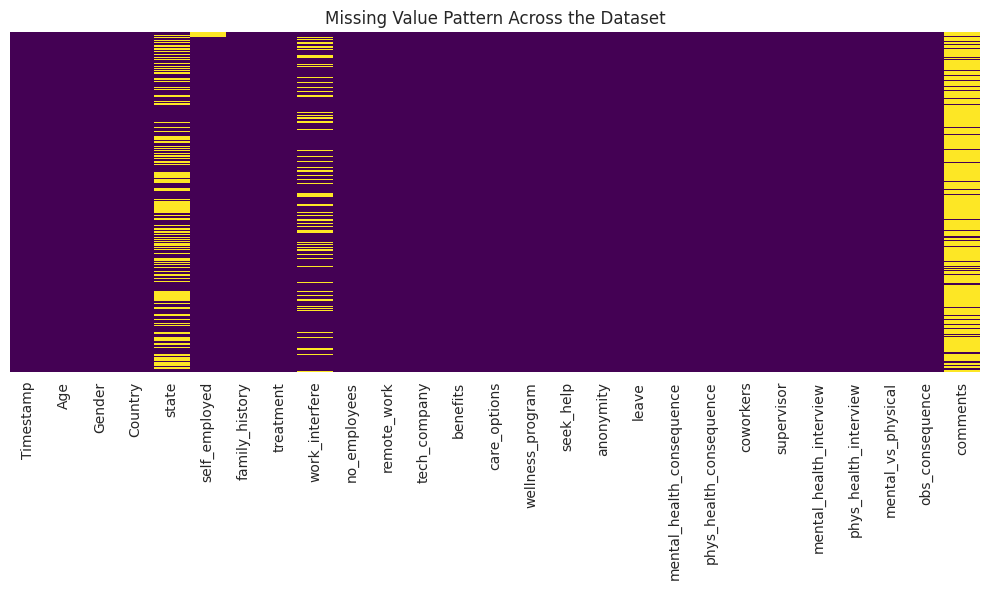

In [8]:
plt.figure(figsize=(10, 6))
sns.heatmap(df.isnull(), cbar=False, yticklabels=False, cmap='viridis')
plt.title('Missing Value Pattern Across the Dataset')
plt.tight_layout()
plt.show()

**### What did you know about your dataset?**

This is a 2014 OSMI survey on mental health attitudes in the tech workplace, with 1,259 responses collected mostly around August 2014. There are 27 columns and no duplicate rows, so nothing needed to be dropped for redundancy.

Missingness sits in four columns for four different reasons. comments is empty for 87% of respondents — it's an optional free-text box most people skipped, and I'll use it later for a word cloud rather than structured analysis. state is missing for 41%, but that's expected since it only applies to US-based respondents — it's "not applicable," not really missing. work_interfere is missing for 21%, which is more meaningful: it was likely only shown to people who reported having a mental health condition, so a blank answer here is informative on its own and shouldn't just be dropped or filled in. self_employed has only 18 gaps, small enough to handle with a simple fill.

Every other column has zero missing values. Age is the only numeric column and will need a closer look in the next section, since a quick scan shows some clearly invalid entries mixed in with real ages.

## ***2. Understanding Your Variables***

### Dataset Columns

In [9]:
df.columns

Index(['Timestamp', 'Age', 'Gender', 'Country', 'state', 'self_employed',
       'family_history', 'treatment', 'work_interfere', 'no_employees',
       'remote_work', 'tech_company', 'benefits', 'care_options',
       'wellness_program', 'seek_help', 'anonymity', 'leave',
       'mental_health_consequence', 'phys_health_consequence', 'coworkers',
       'supervisor', 'mental_health_interview', 'phys_health_interview',
       'mental_vs_physical', 'obs_consequence', 'comments'],
      dtype='object')

**### Dataset Describe**

In [10]:
df.describe()

,Age
count,1.259000e+03
mean,7.942815e+07
std,2.818299e+09
min,-1.726000e+03
25%,2.700000e+01
50%,3.100000e+01
75%,3.600000e+01
max,1.000000e+11


**### Variables Description**



*   **Timestamp:** Date and time the    response was submitted
*   **Age:** Respondent's age

*   **Gender:** Respondent's self-reported gender (free text)
*   **Country:** Respondent's country

*   **state:** If living in the United States, which state or territory
*   **self_employed:** Whether the respondent is self-employed

*   **family_history:** Whether the respondent has a family history of mental illness
*   **treatment:** Whether the respondent has sought treatment for a mental health condition

*   **work_interfere:** If the respondent has a mental health condition, whether it interferes with their work
*   **no_employees:** Number of employees in the respondent's company

*   **remote_work:** Whether the respondent works remotely at least 50% of the time
*   **tech_company:** Whether the respondent's employer is primarily a tech company

*   **benefits:** Whether the employer provides mental health benefits
*   **care_options:** Whether the respondent knows the mental health care options their employer provides

*   **wellness_program:** Whether the employer has discussed mental health as part of an employee wellness program
*   **seek_help:** Whether the employer provides resources to learn about mental health and how to seek help

*   **anonymity:** Whether anonymity is protected if the respondent uses mental health/substance abuse treatment resources
*   **leave:** How easy it is to take medical leave for a mental health condition

*   **mental_health_consequence:** Whether discussing a mental health issue with the employer would have negative consequences
*   **phys_health_consequence:** Whether discussing a physical health issue with the employer would have negative consequences

*   **coworkers:** Willingness to discuss a mental health issue with coworkers
*   **supervisor:** Willingness to discuss a mental health issue with a direct supervisor

*   **mental_health_interview:** Whether the respondent would bring up a mental health issue in a job interview
*   **phys_health_interview:** Whether
the respondent would bring up a physical health issue in a job interview

*   **mental_vs_physical:** Whether the respondent feels their employer takes mental health as seriously as physical health
*   **obs_consequence:** Whether the respondent has observed negative consequences for coworkers with mental health conditions

*   **comments:** Optional free-text notes from the respondent






























**### Check Unique Values for each variable.**

In [11]:
for col in df.columns:
    print(f"{col}: {df[col].nunique()} unique values")

Timestamp: 1246 unique values
Age: 53 unique values
Gender: 49 unique values
Country: 48 unique values
state: 45 unique values
self_employed: 2 unique values
family_history: 2 unique values
treatment: 2 unique values
work_interfere: 4 unique values
no_employees: 6 unique values
remote_work: 2 unique values
tech_company: 2 unique values
benefits: 3 unique values
care_options: 3 unique values
wellness_program: 3 unique values
seek_help: 3 unique values
anonymity: 3 unique values
leave: 5 unique values
mental_health_consequence: 3 unique values
phys_health_consequence: 3 unique values
coworkers: 3 unique values
supervisor: 3 unique values
mental_health_interview: 3 unique values
phys_health_interview: 3 unique values
mental_vs_physical: 3 unique values
obs_consequence: 2 unique values
comments: 160 unique values


## 3. ***Data Wrangling***

### Data Wrangling Code

In [12]:
print(sorted(df['Gender'].unique(), key=str.lower))

['A little about you', 'Agender', 'All', 'Androgyne', 'Cis Female', 'Cis Male', 'cis male', 'Cis Man', 'cis-female/femme', 'Enby', 'F', 'f', 'femail', 'Femake', 'Female', 'female', 'Female ', 'Female (cis)', 'Female (trans)', 'fluid', 'Genderqueer', 'Guy (-ish) ^_^', 'M', 'm', 'Mail', 'maile', 'Make', 'Mal', 'Male', 'male', 'Male ', 'Male (CIS)', 'male leaning androgynous', 'Male-ish', 'Malr', 'Man', 'msle', 'Nah', 'Neuter', 'non-binary', 'ostensibly male, unsure what that really means', 'p', 'queer', 'queer/she/they', 'something kinda male?', 'Trans woman', 'Trans-female', 'Woman', 'woman']


In [13]:
def clean_gender(g):
    g = str(g).strip().lower()

    male_set = {'male', 'm', 'mail', 'maile', 'make', 'mal', 'male (cis)',
                'male-ish', 'malr', 'man', 'msle', 'cis male', 'cis man',
                'male leaning androgynous',
                'ostensibly male, unsure what that really means',
                'something kinda male?', 'guy (-ish) ^_^'}

    female_set = {'female', 'f', 'femail', 'femake', 'female (cis)',
                  'female (trans)', 'cis female', 'cis-female/femme',
                  'woman', 'trans woman', 'trans-female'}

    if g in male_set:
        return 'Male'
    elif g in female_set:
        return 'Female'
    else:
        return 'Other'

df['Gender_clean'] = df['Gender'].apply(clean_gender)
df['Gender_clean'].value_counts()

,count
Gender_clean,
Male,995
Female,251
Other,13


In [14]:
# See exactly how many rows are affected before filtering
invalid_age = df[(df['Age'] < 18) | (df['Age'] > 75)]
print(f"Invalid age rows: {len(invalid_age)}")
print(sorted(invalid_age['Age'].tolist()))

Invalid age rows: 8
[-1726, -29, -1, 5, 8, 11, 329, 99999999999]


In [15]:
df = df[(df['Age'] >= 18) & (df['Age'] <= 75)].reset_index(drop=True)
print(f"Rows remaining: {len(df)}")

Rows remaining: 1251


In [16]:
df['self_employed'].value_counts(dropna=False)

,count
self_employed,
No,1091
Yes,142
NaN,18


In [17]:
df['self_employed'] = df['self_employed'].fillna('No')
print(df['self_employed'].isnull().sum())

0


In [18]:
pd.crosstab(df['work_interfere'].isnull(), df['treatment'])

treatment,No,Yes
work_interfere,,
False,361,628
True,258,4


In [19]:
df['work_interfere'] = df['work_interfere'].fillna('Not applicable')
print(df['work_interfere'].value_counts())

work_interfere
Sometimes         464
Not applicable    262
Never             212
Rarely            173
Often             140
Name: count, dtype: int64


In [20]:
non_us_with_state = df[(df['Country'] != 'United States') & (df['state'].notnull())]
print(f"Non-US rows with a state value: {len(non_us_with_state)}")

us_missing_state = df[(df['Country'] == 'United States') & (df['state'].isnull())]
print(f"US rows missing state: {len(us_missing_state)}")

Non-US rows with a state value: 3
US rows missing state: 11


In [21]:
df[(df['Country'] != 'United States') & (df['state'].notnull())][['Country', 'state']]

,Country,state
318,Latvia,NY
485,Israel,MD
1171,Bulgaria,UT


state is missing for non-US respondents as expected, with one minor exception: 3 non-US rows have a state value anyway (likely a data entry quirk), and 11 US respondents left the field blank. Both are left as NaN/as-is — the field is only meaningful for US respondents, and these edge cases are too small to affect the analysis. comments is also left as NaN — it's optional free text, and the nulls will simply be excluded when building the word cloud in Section 4.

In [22]:
binary_map = {'Yes': 1, 'No': 0}

binary_cols = ['self_employed', 'family_history', 'treatment', 'remote_work',
               'tech_company', 'obs_consequence']

mapping_table = pd.DataFrame({
    'Column': binary_cols,
    'Mapping': ['Yes=1, No=0'] * len(binary_cols)
})
mapping_table

,Column,Mapping
0,self_employed,"Yes=1, No=0"
1,family_history,"Yes=1, No=0"
2,treatment,"Yes=1, No=0"
3,remote_work,"Yes=1, No=0"
4,tech_company,"Yes=1, No=0"
5,obs_consequence,"Yes=1, No=0"


In [23]:
for col in binary_cols:
    df[col + '_num'] = df[col].map(binary_map)

df[[c + '_num' for c in binary_cols]].head()

,self_employed_num,family_history_num,treatment_num,remote_work_num,tech_company_num,obs_consequence_num
0,0,0,1,0,1,0
1,0,0,0,0,0,0
2,0,0,0,0,1,0
3,0,1,1,0,1,1
4,0,0,0,1,1,0


In [24]:
multi_cols = ['work_interfere', 'no_employees', 'benefits', 'care_options',
              'wellness_program', 'seek_help', 'anonymity', 'leave',
              'mental_health_consequence', 'phys_health_consequence',
              'coworkers', 'supervisor', 'mental_health_interview',
              'phys_health_interview', 'mental_vs_physical']

for col in multi_cols:
    print(f"{col}: {sorted(df[col].unique(), key=str)}")
    print()

work_interfere: ['Never', 'Not applicable', 'Often', 'Rarely', 'Sometimes']

no_employees: ['1-5', '100-500', '26-100', '500-1000', '6-25', 'More than 1000']

benefits: ["Don't know", 'No', 'Yes']

care_options: ['No', 'Not sure', 'Yes']

wellness_program: ["Don't know", 'No', 'Yes']

seek_help: ["Don't know", 'No', 'Yes']

anonymity: ["Don't know", 'No', 'Yes']

leave: ["Don't know", 'Somewhat difficult', 'Somewhat easy', 'Very difficult', 'Very easy']

mental_health_consequence: ['Maybe', 'No', 'Yes']

phys_health_consequence: ['Maybe', 'No', 'Yes']

coworkers: ['No', 'Some of them', 'Yes']

supervisor: ['No', 'Some of them', 'Yes']

mental_health_interview: ['Maybe', 'No', 'Yes']

phys_health_interview: ['Maybe', 'No', 'Yes']

mental_vs_physical: ["Don't know", 'No', 'Yes']



In [25]:
ordinal_maps = {
    'work_interfere': {'Never': 0, 'Rarely': 1, 'Sometimes': 2, 'Often': 3, 'Not applicable': -1},
    'no_employees': {'1-5': 0, '6-25': 1, '26-100': 2, '100-500': 3, '500-1000': 4, 'More than 1000': 5},
    'leave': {'Very easy': 0, 'Somewhat easy': 1, "Don't know": -1, 'Somewhat difficult': 2, 'Very difficult': 3}
}

for col, mapping in ordinal_maps.items():
    df[col + '_num'] = df[col].map(mapping)

df[['work_interfere_num', 'no_employees_num', 'leave_num']].head()

,work_interfere_num,no_employees_num,leave_num
0,3,1,1
1,1,5,-1
2,1,1,2
3,3,2,2
4,0,3,-1


In [26]:
nominal_map = {'Yes': 1, 'No': 0, "Don't know": 0.5, 'Not sure': 0.5,
               'Maybe': 0.5, 'Some of them': 0.5}

nominal_cols = ['benefits', 'care_options', 'wellness_program', 'seek_help',
                 'anonymity', 'mental_health_consequence', 'phys_health_consequence',
                 'coworkers', 'supervisor', 'mental_health_interview',
                 'phys_health_interview', 'mental_vs_physical']

for col in nominal_cols:
    df[col + '_num'] = df[col].map(nominal_map)

df[[c + '_num' for c in nominal_cols]].head()

,benefits_num,care_options_num,wellness_program_num,seek_help_num,anonymity_num,mental_health_consequence_num,phys_health_consequence_num,coworkers_num,supervisor_num,mental_health_interview_num,phys_health_interview_num,mental_vs_physical_num
0,1.0,0.5,0.0,1.0,1.0,0.0,0.0,0.5,1.0,0.0,0.5,1.0
1,0.5,0.0,0.5,0.5,0.5,0.5,0.0,0.0,0.0,0.0,0.0,0.5
2,0.0,0.0,0.0,0.0,0.5,0.0,0.0,1.0,1.0,1.0,1.0,0.0
3,0.0,1.0,0.0,0.0,0.0,1.0,1.0,0.5,0.0,0.5,0.5,0.0
4,1.0,0.0,0.5,0.5,0.5,0.0,0.0,0.5,1.0,1.0,1.0,0.5


work_interfere, no_employees, and leave were encoded ordinally, since each has a genuine low-to-high scale. "Not applicable" and "Don't know" were given -1 rather than 0, since they represent a non-answer, not the lowest point on the scale. The remaining Yes/No/Uncertain columns (benefits, care_options, coworkers, etc.) were encoded as Yes=1, No=0, and any uncertain answer (Don't know / Maybe / Not sure / Some of them) = 0.5, since these are genuine middle positions rather than missing data.

**What manipulations have you done and insights you found?**

I cleaned Gender's 49 free-text variants into three buckets — Male (995), Female (251), Other (13) — using an explicit set-based mapping rather than a regex, since substring matching risks false positives like "female" matching "male."

I filtered 8 rows with clearly invalid Age values (negative numbers, an 11-digit entry, ages under 18), leaving 1,251 usable rows.

self_employed's 18 nulls were filled with the majority answer (No), since the gap was too small to affect the distribution. work_interfere's 264 nulls were left as an explicit "Not applicable" category rather than filled or dropped, after confirming with a crosstab that 258 of those 262 missing rows belonged to people who never sought treatment — the missingness itself was meaningful, not random. state and comments were left as NaN, since both represent genuine non-answers (state only applies to US respondents, comments is optional free text).

All Yes/No fields were mapped to 1/0, ordinal fields (work_interfere, no_employees, leave) were mapped to a numeric scale with -1 reserved for non-answers, and the remaining Yes/No/Uncertain fields were mapped with 0.5 for uncertain answers rather than forcing them toward Yes or No. This keeps every encoded field usable in the correlation heatmap without misrepresenting missing or uncertain responses as something they weren't.

## ***4. Data Vizualization, Storytelling & Experimenting with charts : Understand the relationships between variables***

**Chart 1: Age Distribution**

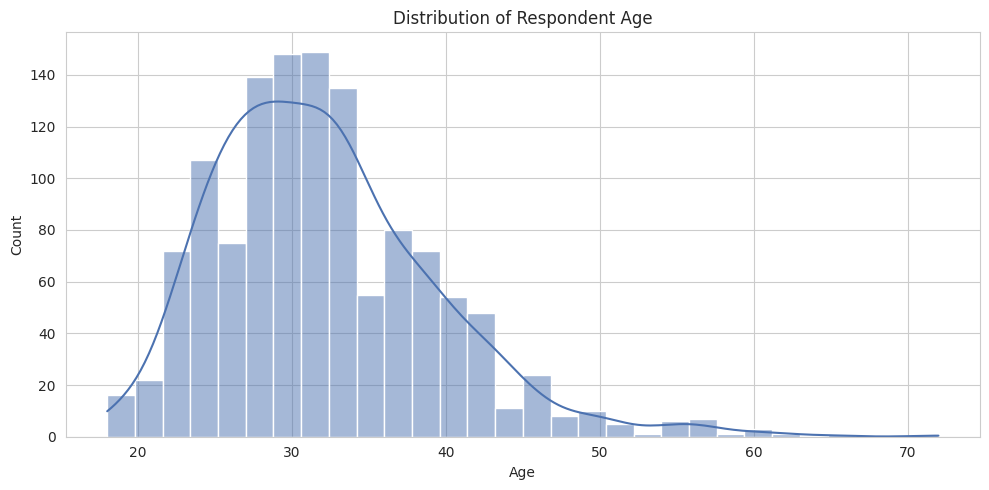

In [27]:
plt.figure(figsize=(10, 5))
sns.histplot(df['Age'], bins=30, kde=True, color='#4C72B0')
plt.title('Distribution of Respondent Age')
plt.xlabel('Age')
plt.ylabel('Count')
plt.tight_layout()
plt.show()

**Why did you pick the specific chart?**
A histogram with a KDE overlay is the standard choice for showing how a single continuous variable is distributed. It shows both the raw bucket counts (bars) and the overall shape (curve) in one view, which is exactly what's needed for a first look at Age.

**What is/are the insight(s) found from the chart?**
The respondent base skews young — most people fall between their mid-20s and early 40s, with the single biggest concentration around 28-32. Very few respondents are under 20 or over 55, so this dataset represents early-to-mid career tech employees far more than late-career ones.

**Will the gained insights help creating a positive business impact? Are there any insights that lead to negative growth? Justify with specific reason.**
This skew is useful context, not a problem to fix — it means any recommendation this analysis produces is really a recommendation for supporting early-to-mid career employees specifically, since that's who the data represents. A company acting on these findings shouldn't assume they apply equally well to a workforce with a lot of employees over 50, since that group is barely represented here

**Chart 2: Gender Distribution**

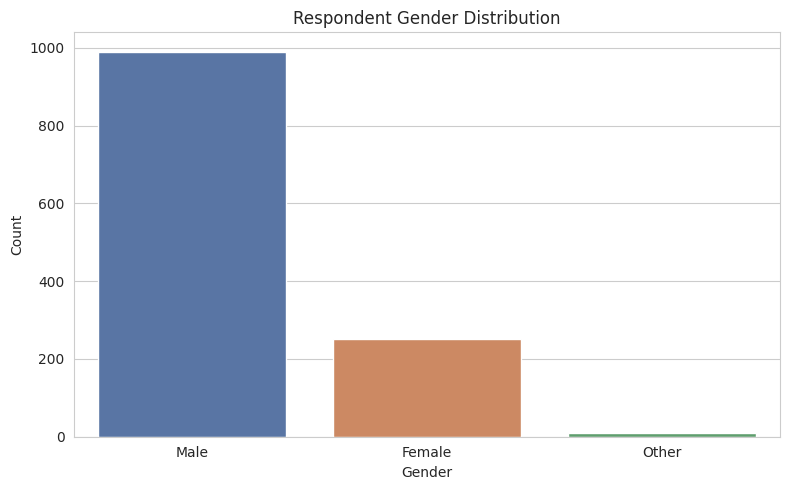

In [28]:
plt.figure(figsize=(8, 5))
gender_counts = df['Gender_clean'].value_counts()
sns.barplot(x=gender_counts.index, y=gender_counts.values, hue=gender_counts.index,
            palette=['#4C72B0', '#DD8452', '#55A868'], legend=False)
plt.title('Respondent Gender Distribution')
plt.xlabel('Gender')
plt.ylabel('Count')
plt.tight_layout()
plt.show()

**Why did you pick the specific chart?**
A simple bar chart is the clearest way to compare counts across a small number of categories, and Gender only has three buckets after cleaning.

**What is/are the insight(s) found from the chart?**
The respondent base is heavily male — about 79% of the sample — with female respondents at roughly 20% and other gender identities at just over 1%. This isn't a finding about mental health itself, it's a sampling characteristic that needs to be kept in mind for every gender-based comparison that follows.

**Will the gained insights help creating a positive business impact? Are there any insights that lead to negative growth? Justify with specific reason.**
This is a caution flag more than a business insight. Any conclusion this analysis draws about how gender relates to treatment-seeking or workplace support is based on a sample where women and non-binary respondents are a small minority, so those specific comparisons carry less statistical weight and shouldn't be treated with the same confidence as the overall findings.

**Chart 3: Top 10 Countries by Respondent Count**

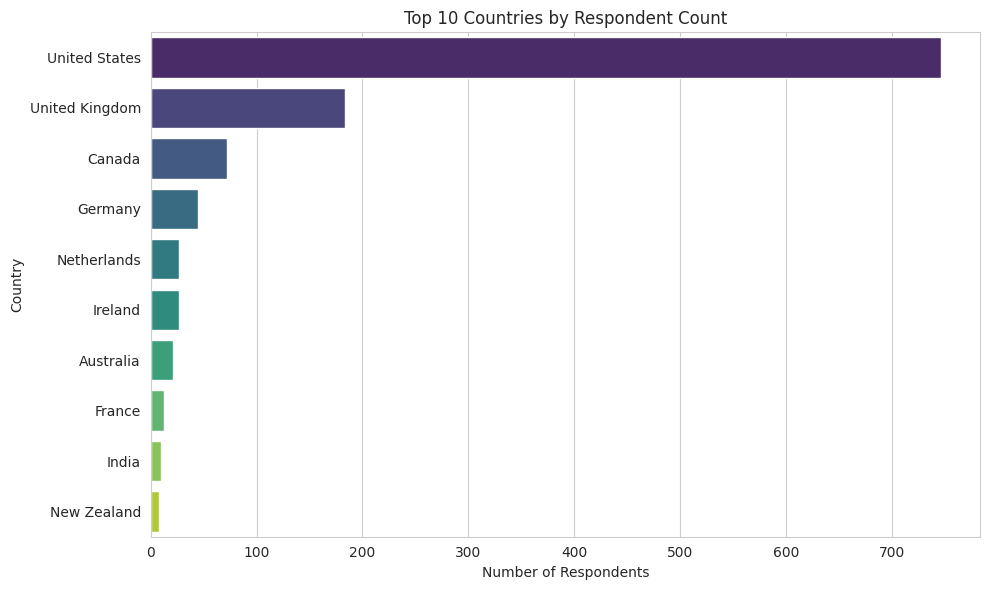

In [29]:
plt.figure(figsize=(10, 6))
top_countries = df['Country'].value_counts().head(10)
sns.barplot(x=top_countries.values, y=top_countries.index, hue=top_countries.index,
            palette='viridis', legend=False)
plt.title('Top 10 Countries by Respondent Count')
plt.xlabel('Number of Respondents')
plt.ylabel('Country')
plt.tight_layout()
plt.show()

**Why did you pick the specific chart?**
A horizontal bar chart works better than a vertical one here because country names are long and there are 10 of them — reading left to right avoids cramped, rotated x-axis labels.

**What is/are the insight(s) found from the chart?**
The United States accounts for roughly 60% of all respondents on its own, with the UK a distant second at about 15%. Every other country contributes a small fraction. This is overwhelmingly a US-centric dataset, not a globally representative one.

**Will the gained insights help creating a positive business impact? Are there any insights that lead to negative growth? Justify with specific reason.**
Any geographic pattern this analysis finds — including the mental_health_consequence or leave questions, which are shaped by local labor law and healthcare systems — is really describing US and UK workplace norms, not a global standard. A company outside those two countries applying these findings directly, without adjusting for local employment law and healthcare access, would be extrapolating from a sample that barely represents their context.

**Chart 4: Treatment Sought — Yes vs No**

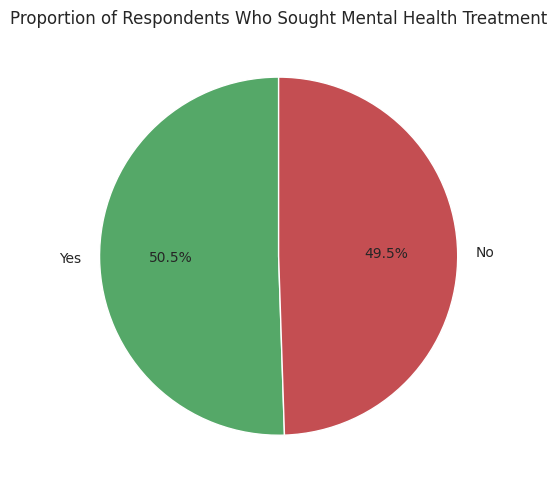

In [30]:
plt.figure(figsize=(7, 5))
treatment_counts = df['treatment'].value_counts()
colors = ['#55A868', '#C44E52']
plt.pie(treatment_counts.values, labels=treatment_counts.index, autopct='%1.1f%%',
        colors=colors, startangle=90)
plt.title('Proportion of Respondents Who Sought Mental Health Treatment')
plt.tight_layout()
plt.show()

**Why did you pick the specific chart?**
A pie chart is appropriate here specifically because it's a two-category proportion that sums to 100% and the split is close to even — it's an easy visual gut-check that a bar chart wouldn't add much over.

**What is/are the insight(s) found from the chart?**
Just over half of respondents (50.5%) have sought treatment for a mental health condition. This directly answers one half of the business objective: treatment-seeking in this sample isn't rare or unusual, it's close to a coin flip.

**Will the gained insights help creating a positive business impact? Are there any insights that lead to negative growth? Justify with specific reason.**
A near-50/50 split is actually a useful baseline for every comparison later in this notebook — if a specific group (like people with a family history, or people at companies with no benefits) shows a treatment rate meaningfully above or below 50%, that's a real signal worth acting on, not just noise. Without this baseline chart, those later percentages wouldn't mean much on their own.

**Chart 5: Family History vs Treatment (crosstab)**

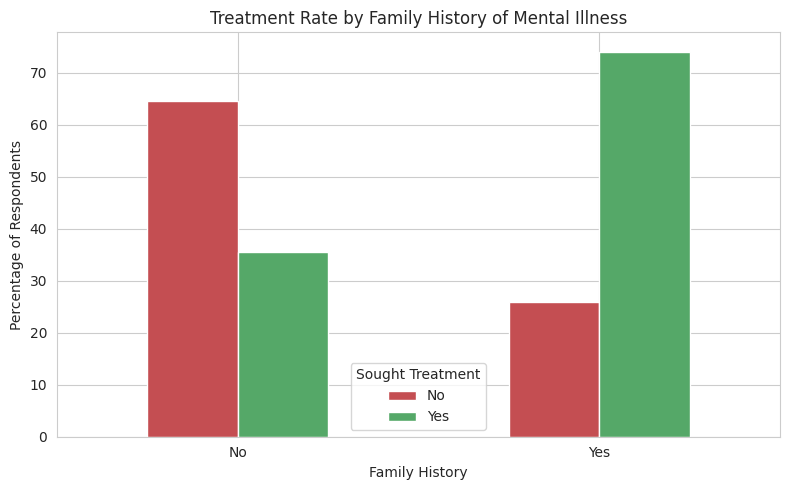

In [31]:
plt.figure(figsize=(8, 5))
ct = pd.crosstab(df['family_history'], df['treatment'], normalize='index') * 100
ct.plot(kind='bar', color=['#C44E52', '#55A868'], ax=plt.gca())
plt.title('Treatment Rate by Family History of Mental Illness')
plt.xlabel('Family History')
plt.ylabel('Percentage of Respondents')
plt.legend(title='Sought Treatment', labels=['No', 'Yes'])
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

**Why did you pick the specific chart?**
A normalized (percentage) grouped bar chart is the right way to compare a rate across two groups of very different sizes — raw counts would be misleading here since far more people report no family history than yes, so converting to within-group percentages makes the comparison fair.

**What is/are the insight(s) found from the chart?**
Family history of mental illness is one of the strongest predictors of treatment-seeking in the whole dataset. People with a family history seek treatment at 74%, compared to 35% for people without one — more than double the rate.

**Will the gained insights help creating a positive business impact? Are there any insights that lead to negative growth? Justify with specific reason.**
This is a genuinely actionable finding for the business objective: family history is a strong enough signal that workplace mental health programs could reasonably target awareness and outreach around it — for example, normalizing conversations about family history in wellness communications, since people without that background are seeking help at less than half the rate. The risk to flag is that this is a correlation, not causation — the data doesn't say family history causes someone to seek treatment, only that it's strongly associated, so recommendations should be framed as "this group needs more outreach," not "this group has more real need."

**Chart 6: Treatment Rate by Company Size (no_employees)**

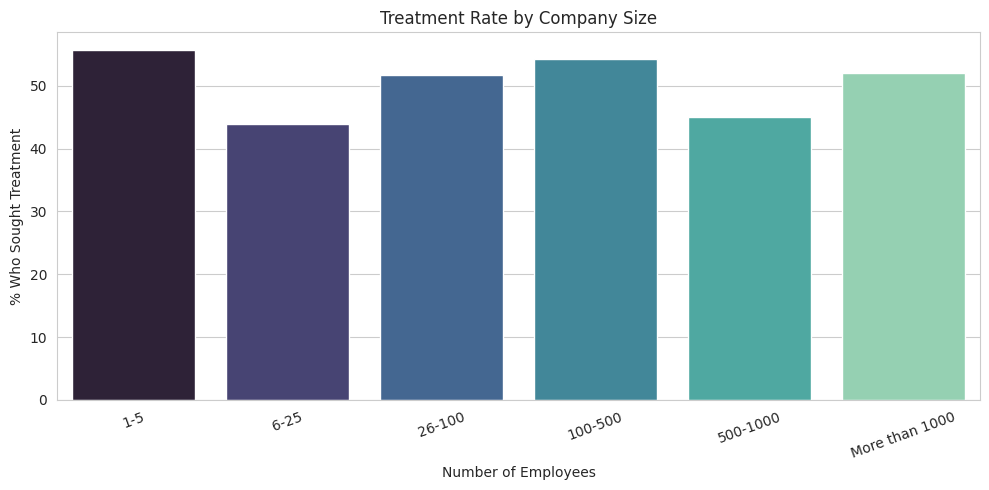

In [32]:
plt.figure(figsize=(10, 5))
size_order = ['1-5', '6-25', '26-100', '100-500', '500-1000', 'More than 1000']
ct = pd.crosstab(df['no_employees'], df['treatment'], normalize='index')['Yes'].reindex(size_order) * 100
sns.barplot(x=ct.index, y=ct.values, hue=ct.index, palette='mako', legend=False)
plt.title('Treatment Rate by Company Size')
plt.xlabel('Number of Employees')
plt.ylabel('% Who Sought Treatment')
plt.xticks(rotation=20)
plt.tight_layout()
plt.show()

**Why did you pick the specific chart?**
A bar chart in the natural size order (smallest to largest company) makes it easy to spot a trend across an ordinal category, if one exists.

**What is/are the insight(s) found from the chart?**
Company size barely matters for treatment-seeking. Every bucket sits between 44% and 56%, and the pattern isn't even monotonic — the smallest companies (1-5 employees) have the highest rate, not the lowest, which rules out a simple "bigger company, more resources, more treatment" story.

**Will the gained insights help creating a positive business impact? Are there any insights that lead to negative growth? Justify with specific reason.**
This is a useful negative finding — it tells the business objective that company size isn't the lever to focus on. A large enterprise shouldn't assume its size alone makes employees more likely to seek help, and a small startup shouldn't assume its size is a barrier. Whatever drives treatment-seeking, it's not simply headcount, which points attention toward the benefits/culture-related questions instead.

**Chart 7: Treatment Rate by Remote Work Status**

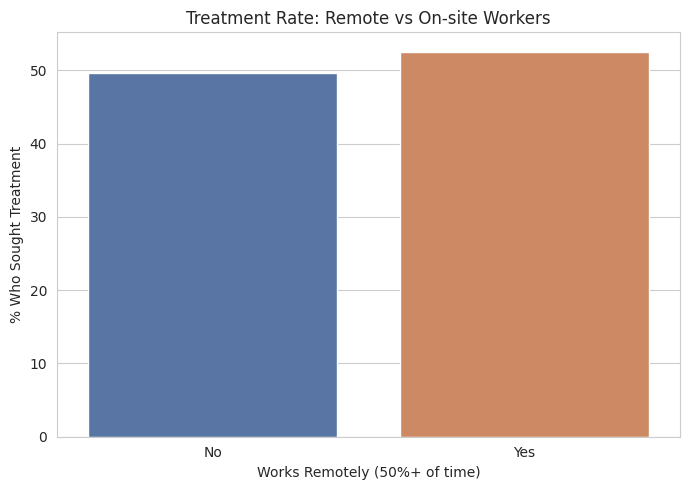

In [33]:
plt.figure(figsize=(7, 5))
ct = pd.crosstab(df['remote_work'], df['treatment'], normalize='index')['Yes'] * 100
sns.barplot(x=ct.index, y=ct.values, hue=ct.index, palette=['#4C72B0', '#DD8452'], legend=False)
plt.title('Treatment Rate: Remote vs On-site Workers')
plt.xlabel('Works Remotely (50%+ of time)')
plt.ylabel('% Who Sought Treatment')
plt.tight_layout()
plt.show()

**Why did you pick the specific chart?**
A two-bar comparison is enough here since remote_work only has two categories, and the goal is just to check whether there's a gap worth reporting.

**What is/are the insight(s) found from the chart?**
Remote work status has almost no relationship with treatment-seeking — a 3-point gap that's well within normal sampling noise for a dataset this size. Whether someone works remotely or on-site doesn't meaningfully predict whether they've sought treatment.

**Will the gained insights help creating a positive business impact? Are there any insights that lead to negative growth? Justify with specific reason.**
Another useful negative finding for the business objective — it rules out remote-work policy as a lever for mental health support. A company shouldn't expect that shifting people to remote or in-office work will move treatment-seeking rates on its own; whatever matters here, it's not physical work location.

**Chart 8: Treatment Rate by Employer-Provided Benefits**

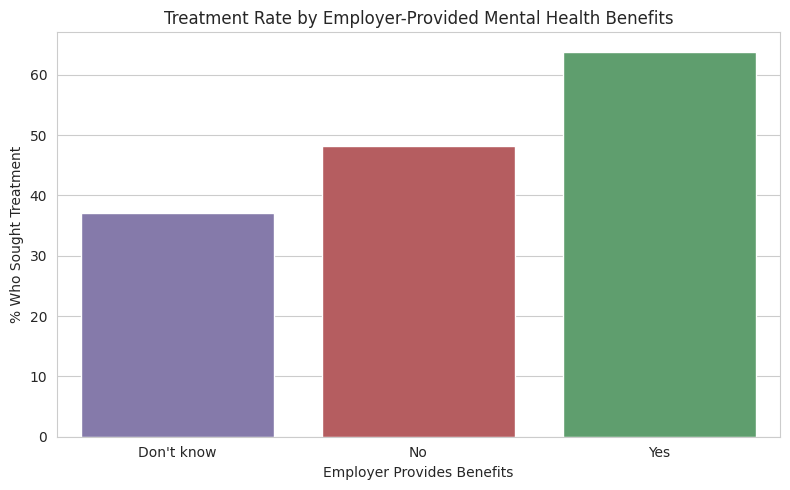

In [34]:
plt.figure(figsize=(8, 5))
ct = pd.crosstab(df['benefits'], df['treatment'], normalize='index')['Yes'].reindex(["Don't know", 'No', 'Yes']) * 100
sns.barplot(x=ct.index, y=ct.values, hue=ct.index, palette=['#8172B2', '#C44E52', '#55A868'], legend=False)
plt.title('Treatment Rate by Employer-Provided Mental Health Benefits')
plt.xlabel('Employer Provides Benefits')
plt.ylabel('% Who Sought Treatment')
plt.tight_layout()
plt.show()

**Why did you pick the specific chart?**
Same approach as the family-history chart — a normalized bar chart comparing treatment rate across the three benefit categories, so the comparison isn't skewed by how many people fall in each group.

**What is/are the insight(s) found from the chart?**
Employees who know their employer provides mental health benefits seek treatment at 64%, compared to 48% for employees whose employer doesn't provide them — and interestingly, employees who simply don't know what their employer offers have the lowest rate of all, at 37%, even lower than a flat "No."

**Will the gained insights help creating a positive business impact? Are there any insights that lead to negative growth? Justify with specific reason.**
This is a directly actionable finding for the business objective. The gap between "Don't know" (37%) and "Yes" (64%) is bigger than the gap between "No" and "Yes" — which suggests that simply communicating existing benefits more clearly could lift treatment-seeking almost as much as adding new benefits would. A company that already offers mental health coverage but doesn't advertise it well may be getting a fraction of the value from that investment.

**Chart 9: Treatment Rate by care_options Awareness**

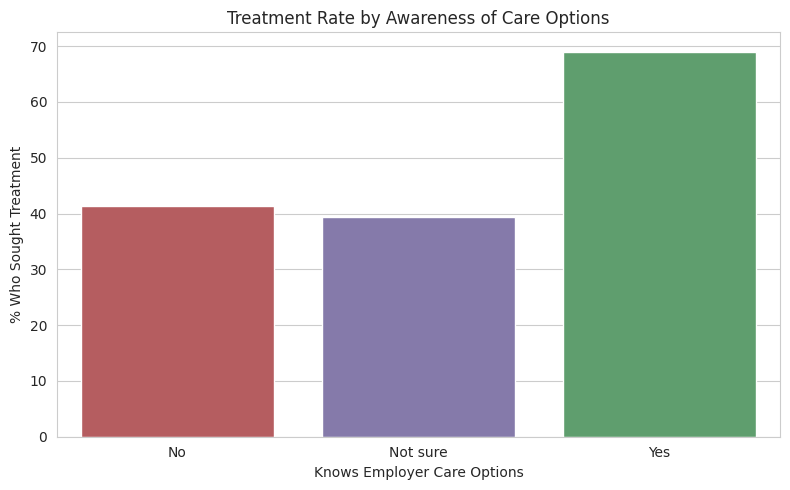

In [35]:
plt.figure(figsize=(8, 5))
ct = pd.crosstab(df['care_options'], df['treatment'], normalize='index')['Yes'].reindex(['No', 'Not sure', 'Yes']) * 100
sns.barplot(x=ct.index, y=ct.values, hue=ct.index, palette=['#C44E52', '#8172B2', '#55A868'], legend=False)
plt.title('Treatment Rate by Awareness of Care Options')
plt.xlabel('Knows Employer Care Options')
plt.ylabel('% Who Sought Treatment')
plt.tight_layout()
plt.show()

**Why did you pick the specific chart?**
Same normalized bar chart approach as the last two, for a direct three-way comparison of treatment rate.

**What is/are the insight(s) found from the chart?**
Knowing what mental health care your employer actually offers is linked to a 69% treatment rate — nearly 30 points higher than employees who don't know or aren't sure (both sit around 40%). This is the strongest employer-related signal in the notebook so far, stronger than benefits alone.

**Will the gained insights help creating a positive business impact? Are there any insights that lead to negative growth? Justify with specific reason.**
This reinforces and sharpens the Chart 8 finding: it's not just about having benefits, it's about employees actually knowing the specifics of what's available. Combined with Chart 8, this makes a strong case that internal communication about existing mental health resources may matter more than adding new ones — a low-cost fix (better onboarding docs, regular reminders, a clear internal page) could move this number meaningfully without any new budget for benefits themselves.

**Chart 10: Willingness to Discuss Mental Health — Coworkers vs Supervisor**

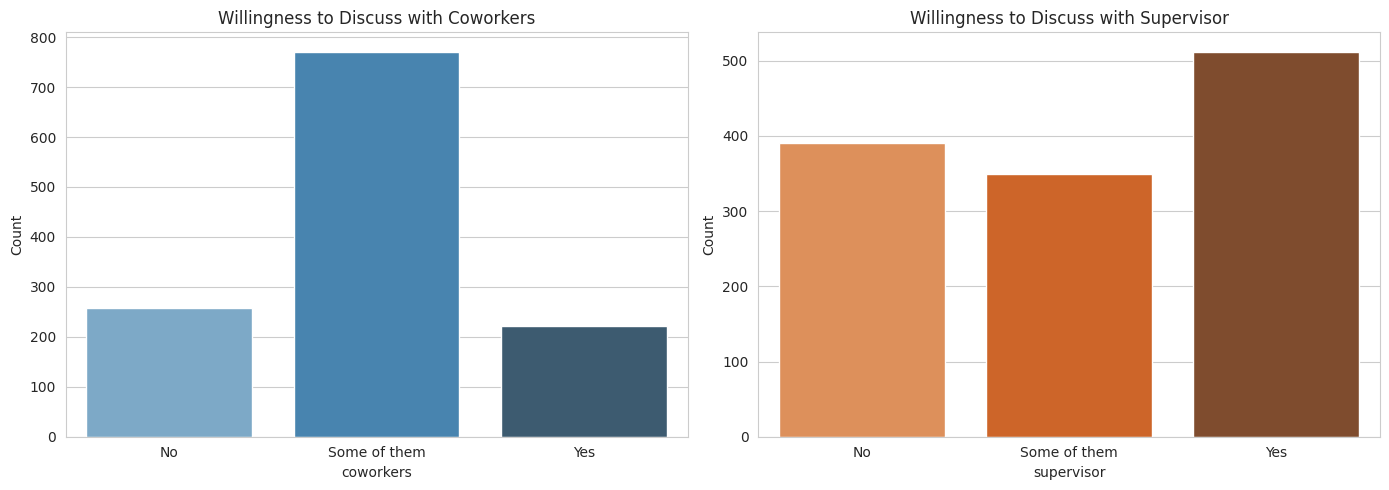

In [36]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

coworker_counts = df['coworkers'].value_counts().reindex(['No', 'Some of them', 'Yes'])
supervisor_counts = df['supervisor'].value_counts().reindex(['No', 'Some of them', 'Yes'])

sns.barplot(x=coworker_counts.index, y=coworker_counts.values, hue=coworker_counts.index,
            palette='Blues_d', legend=False, ax=axes[0])
axes[0].set_title('Willingness to Discuss with Coworkers')
axes[0].set_ylabel('Count')

sns.barplot(x=supervisor_counts.index, y=supervisor_counts.values, hue=supervisor_counts.index,
            palette='Oranges_d', legend=False, ax=axes[1])
axes[1].set_title('Willingness to Discuss with Supervisor')
axes[1].set_ylabel('Count')

plt.tight_layout()
plt.show()

**Why did you pick the specific chart?**
Two side-by-side bar charts let you compare the shape of two related questions directly, without needing to overlay them or force them into one crowded chart.

**What is/are the insight(s) found from the chart?**
With coworkers, people are mostly selective — "Some of them" is the dominant answer at 61% of respondents, far more common than a flat Yes or No. With supervisors, the pattern is different and somewhat counterintuitive: "Yes" is actually the single most common answer (about 41%), ahead of both "No" and "Some of them." Respondents are more all-or-nothing about supervisors than about coworkers, and more willing to open up to a supervisor specifically than the stereotype of "never tell your boss" would suggest.

**Will the gained insights help creating a positive business impact? Are there any insights that lead to negative growth? Justify with specific reason.**
This challenges an assumption a company might make by default — that employees mainly need peer support programs because they won't talk to management. The data suggests supervisor relationships are actually a viable channel for mental health conversations for a large share of employees, which means manager training on how to respond to these conversations well could be as valuable as peer-support initiatives, not a fallback after them.

**Chart 11: Willingness to Discuss vs Perceived Consequences**

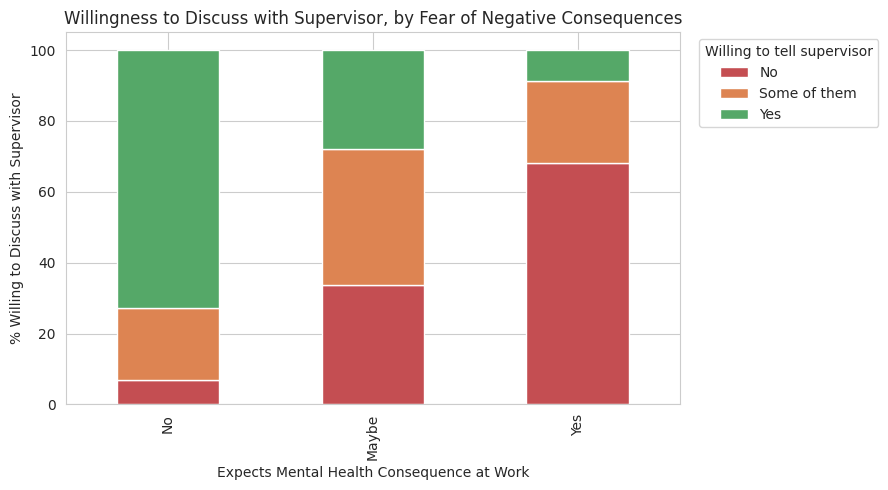

In [37]:
plt.figure(figsize=(9, 5))
ct = pd.crosstab(df['mental_health_consequence'], df['supervisor'], normalize='index') * 100
ct = ct.reindex(['No', 'Maybe', 'Yes'])[['No', 'Some of them', 'Yes']]
ct.plot(kind='bar', stacked=True, color=['#C44E52', '#DD8452', '#55A868'], ax=plt.gca())
plt.title('Willingness to Discuss with Supervisor, by Fear of Negative Consequences')
plt.xlabel('Expects Mental Health Consequence at Work')
plt.ylabel('% Willing to Discuss with Supervisor')
plt.legend(title='Willing to tell supervisor', bbox_to_anchor=(1.02, 1), loc='upper left')
plt.tight_layout()
plt.show()

**Why did you pick the specific chart?**
A stacked, normalized bar chart is the right tool for showing how the full distribution of one categorical variable shifts across levels of another — here, how willingness to tell a supervisor changes as fear of consequences increases from No to Maybe to Yes.

**What is/are the insight(s) found from the chart?**
Fear of negative consequences almost completely determines willingness to talk to a supervisor. Among people who don't expect any consequence, 73% would tell their supervisor. Among people who do expect a consequence, that collapses to under 10%, with 68% flatly saying no. This is one of the cleanest cause-and-effect-shaped patterns in the whole dataset.

**Will the gained insights help creating a positive business impact? Are there any insights that lead to negative growth? Justify with specific reason.**
This is the clearest actionable insight tied to the business objective so far: workplace culture around psychological safety isn't a soft, secondary factor — it's the dominant driver of whether people will actually use the human channel (their supervisor) to get support. A company that wants employees to feel comfortable disclosing mental health issues needs to visibly demonstrate that doing so carries no consequence, since the fear itself — not the actual benefits or policies — is what's shutting people down.

**Chart 12: Anonymity Protection vs Willingness to Seek Help Resources**

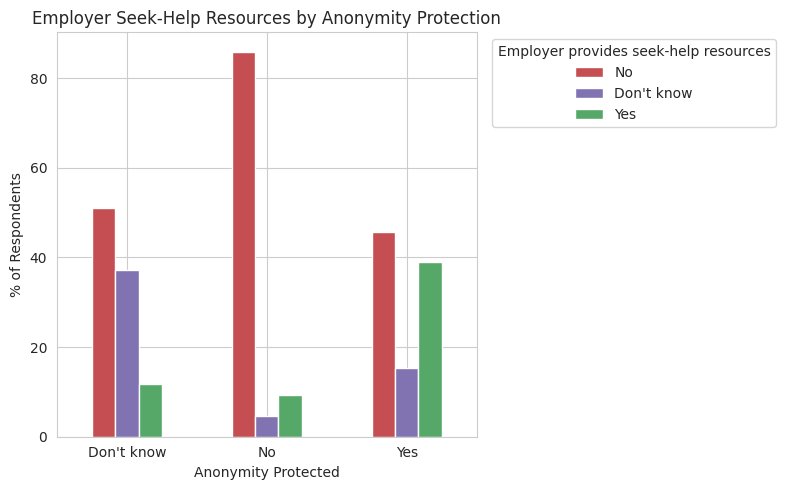

In [38]:
plt.figure(figsize=(8, 5))
ct = pd.crosstab(df['anonymity'], df['seek_help'], normalize='index').reindex(["Don't know", 'No', 'Yes']) * 100
ct = ct[['No', "Don't know", 'Yes']]
ct.plot(kind='bar', color=['#C44E52', '#8172B2', '#55A868'], ax=plt.gca())
plt.title('Employer Seek-Help Resources by Anonymity Protection')
plt.xlabel('Anonymity Protected')
plt.ylabel('% of Respondents')
plt.legend(title='Employer provides seek-help resources', bbox_to_anchor=(1.02, 1), loc='upper left')
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

**Why did you pick the specific chart?**
A grouped (not stacked) bar chart makes it easy to compare all three seek_help categories side by side within each anonymity group, which matters here since the interesting comparison is "Yes" specifically rising, not just the overall shape shifting.

**What is/are the insight(s) found from the chart?**
Anonymity protection and seek-help resources move together. Where anonymity is protected, 39% of employers also provide seek-help resources — more than four times the rate seen where anonymity is not protected (9%). These aren't two independent policies; they behave like a single bundled package that supportive employers offer together, and unsupportive employers skip together.

**Will the gained insights help creating a positive business impact? Are there any insights that lead to negative growth? Justify with specific reason.**
This tells a company that these two policies reinforce each other rather than substitute for each other — adding seek-help resources without also guaranteeing anonymity is likely to underperform, since employees may not trust or use resources if they fear being identified. For maximum impact, the business objective points toward rolling these out as a paired initiative, not two separate line items.

**Chart 13: Age Group vs Treatment Rate**

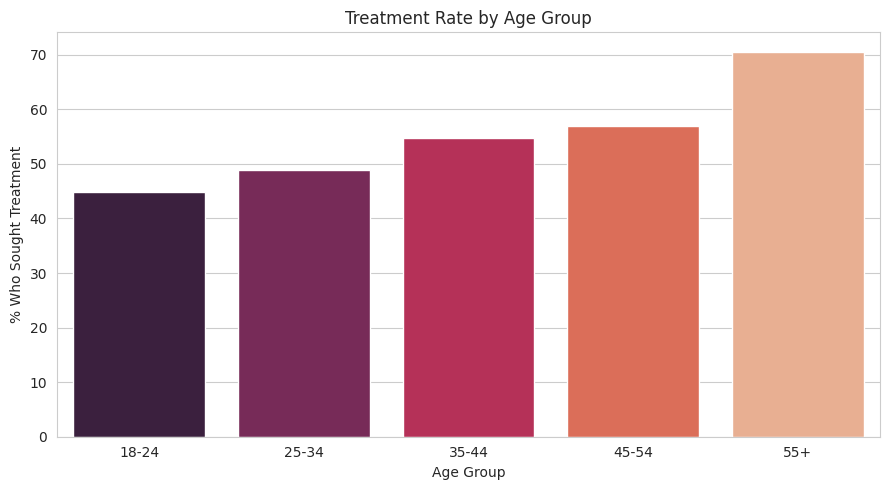

In [39]:
plt.figure(figsize=(9, 5))
df['Age_group'] = pd.cut(df['Age'], bins=[17, 24, 34, 44, 54, 75],
                          labels=['18-24', '25-34', '35-44', '45-54', '55+'])
ct = pd.crosstab(df['Age_group'], df['treatment'], normalize='index')['Yes'] * 100
sns.barplot(x=ct.index, y=ct.values, hue=ct.index, palette='rocket', legend=False)
plt.title('Treatment Rate by Age Group')
plt.xlabel('Age Group')
plt.ylabel('% Who Sought Treatment')
plt.tight_layout()
plt.show()

In [40]:
df['Age_group'].value_counts()

,count
Age_group,
25-34,707
35-44,320
18-24,156
45-54,51
55+,17


**Why did you pick the specific chart?**
Age was bucketed into 5 groups rather than plotted continuously, since treatment rate is a percentage per group, not a per-person value — a bar chart across ordered age bands makes the trend readable in a way a scatter plot of raw Age wouldn't.

**What is/are the insight(s) found from the chart?**
Treatment-seeking rises steadily with age, from 45% in the 18-24 group up to around 70% in the 55+ group. The trend across 18-24 through 45-54 is well-supported (156 to 707 respondents per group), but the 55+ figure rests on just 17 respondents — directionally consistent with the trend, but too small a sample to state with real confidence.

**Will the gained insights help creating a positive business impact? Are there any insights that lead to negative growth? Justify with specific reason.**
This suggests younger employees are the group least likely to seek treatment even when they may need it, which is useful for the business objective — outreach and awareness efforts may have more room to make a difference among early-career employees than older ones, who already seek help at a higher baseline rate. The 55+ group specifically shouldn't drive any recommendation on its own, given the sample size.

**Chart 14: Correlation Heatmap**

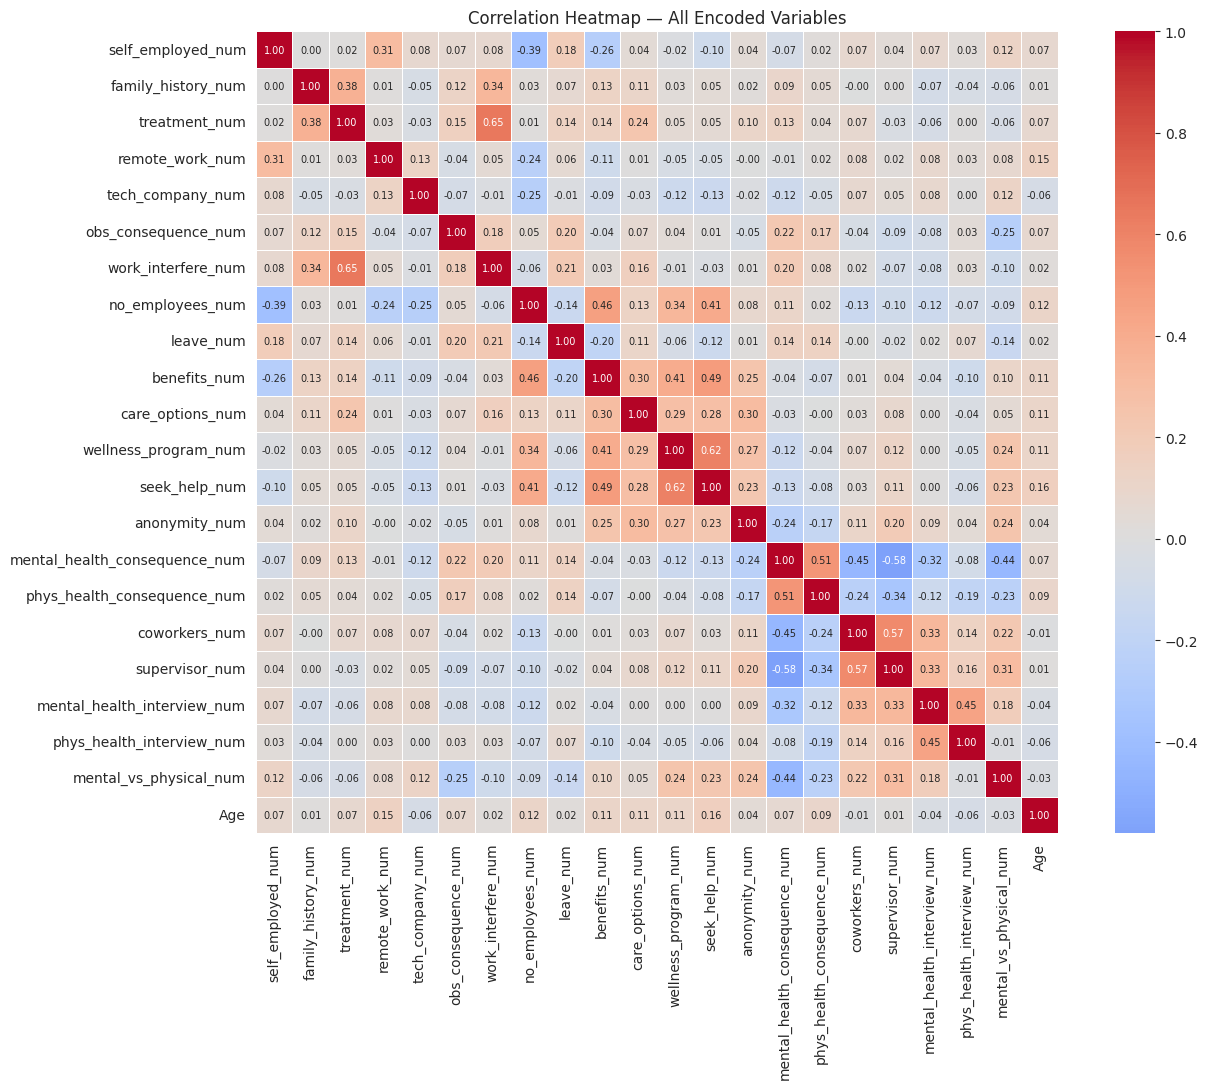

In [41]:
numeric_cols = [c for c in df.columns if c.endswith('_num')] + ['Age']

plt.figure(figsize=(14, 11))
corr = df[numeric_cols].corr()
sns.heatmap(corr, annot=True, fmt='.2f', cmap='coolwarm', center=0,
            square=True, linewidths=0.5, annot_kws={'size': 7})
plt.title('Correlation Heatmap — All Encoded Variables')
plt.tight_layout()
plt.show()

**Why did you pick the specific chart?**
A correlation heatmap gives a single view of how every encoded variable relates to every other one, which is useful for confirming (or catching contradictions in) the bivariate patterns found chart by chart, and for spotting any relationship that wasn't checked individually.

**What is/are the insight(s) found from the chart?**
treatment_num correlates most strongly with work_interfere_num (0.65), though that figure is partly an artifact of how skip-logic nulls were encoded in Section 3, rather than a fresh finding. The more independently meaningful correlations are family_history_num (0.38) and care_options_num (0.24), both consistent with Charts 5 and 9. Separately, mental_health_consequence_num and supervisor_num show a strong negative correlation (-0.58), confirming Chart 11's finding that fear of consequences and willingness to disclose move in opposite directions.

**Will the gained insights help creating a positive business impact? Are there any insights that lead to negative growth? Justify with specific reason.**
The heatmap doesn't surface a new lever beyond what the individual charts already found, but it does validate that family history, care-options awareness, and psychological safety around supervisors are the three strongest, most consistent signals in the dataset — which means a business recommendation built on those three has real support across multiple angles of the analysis, not just one chart in isolation.

**Chart 15: Word Cloud from Comments**

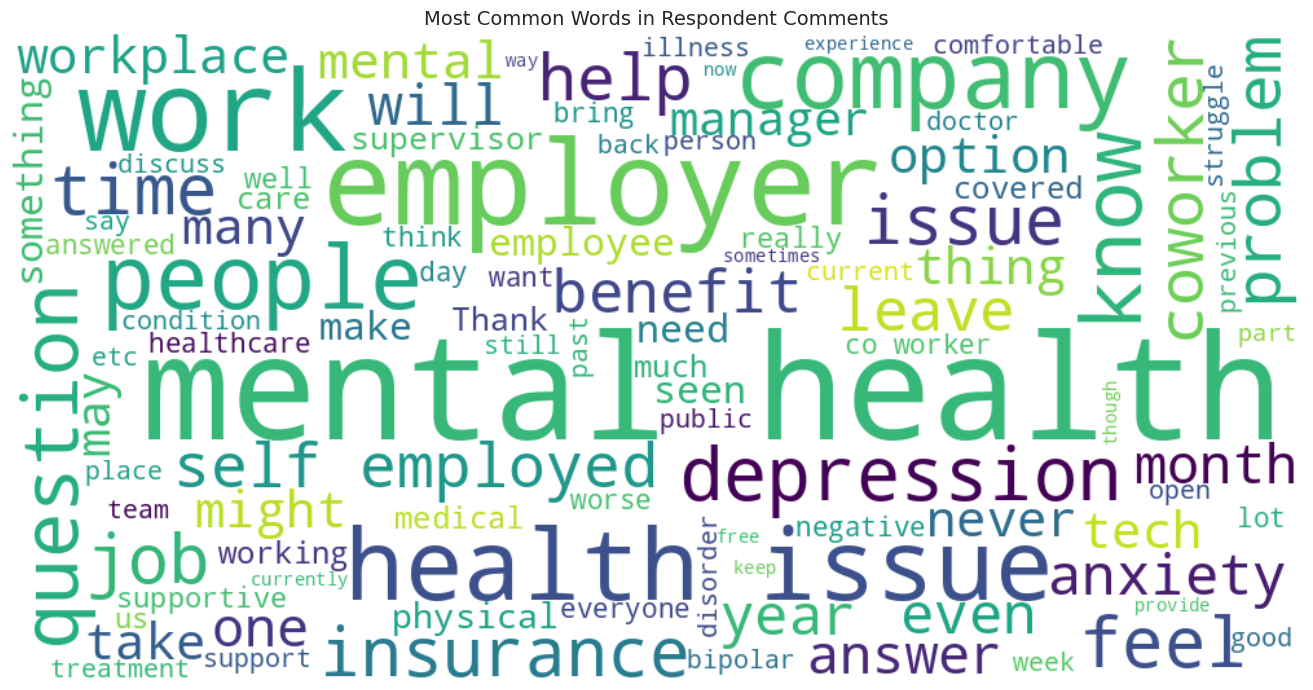

In [42]:
from wordcloud import WordCloud

comments_text = ' '.join(df['comments'].dropna().astype(str))

wc = WordCloud(width=1000, height=500, background_color='white',
                colormap='viridis', max_words=100).generate(comments_text)

plt.figure(figsize=(14, 7))
plt.imshow(wc, interpolation='bilinear')
plt.axis('off')
plt.title('Most Common Words in Respondent Comments', fontsize=14)
plt.tight_layout()
plt.show()

**Why did you pick the specific chart?**
A word cloud is the standard way to surface the dominant themes in unstructured free text at a glance, without reading all 164 comments individually. It replaces the template's pair plot slot, since a pair plot needs multiple continuous variables to be meaningful and this dataset only has one (Age).

**What is/are the insight(s) found from the chart?**
The comments cluster around three themes: the employer relationship (employer, company, manager, benefit, coworker), the act of disclosure itself (issue, question, comfortable, discuss, leave), and specific conditions (depression, anxiety, bipolar). Respondents weren't just answering the survey mechanically — they were writing about real, specific experiences with naming their own conditions and describing workplace dynamics.

**Will the gained insights help creating a positive business impact? Are there any insights that lead to negative growth? Justify with specific reason.**
This qualitative layer backs up the quantitative findings rather than adding a new direction — the same themes (employer support, supervisor relationships, fear around disclosure) that drove the strongest charts in this notebook are the same things people chose to write about unprompted. That convergence between what the numbers show and what people said in their own words makes the case study stronger when presenting the recommendations.

**Chart 16: Tech Company vs Treatment Rate**

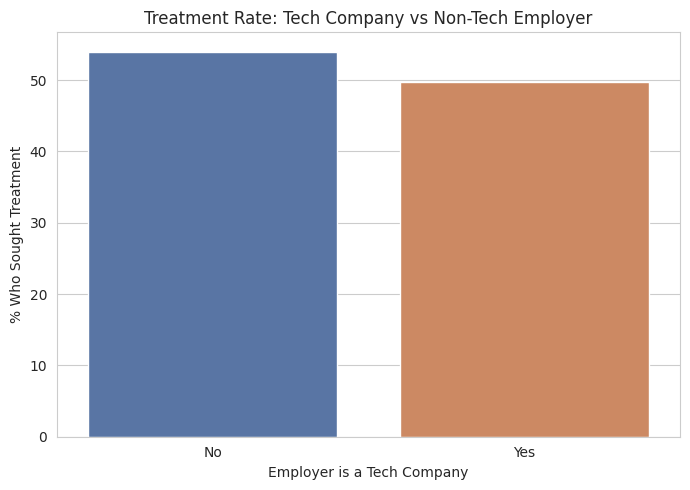

In [43]:
plt.figure(figsize=(7, 5))
ct = pd.crosstab(df['tech_company'], df['treatment'], normalize='index')['Yes'] * 100
sns.barplot(x=ct.index, y=ct.values, hue=ct.index, palette=['#4C72B0', '#DD8452'], legend=False)
plt.title('Treatment Rate: Tech Company vs Non-Tech Employer')
plt.xlabel('Employer is a Tech Company')
plt.ylabel('% Who Sought Treatment')
plt.tight_layout()
plt.show()

**Why did you pick the specific chart?**
Same two-bar comparison approach as the remote-work chart, since tech_company is also binary.

**What is/are the insight(s) found from the chart?**
There's barely a difference — 54% for non-tech employers versus 50% for tech companies, a 4-point gap that's not meaningful given the group sizes. Working at a tech company specifically doesn't predict treatment-seeking one way or the other.

**Will the gained insights help creating a positive business impact? Are there any insights that lead to negative growth? Justify with specific reason.**
This is worth stating plainly since it cuts against a common assumption: being in tech doesn't automatically mean better mental health support or more open culture around it. The business objective shouldn't assume "we're a tech company" is itself protective — the real drivers found elsewhere in this notebook (family history awareness, benefits communication, psychological safety with supervisors) matter regardless of industry.

**Chart 17: Ease of Taking Leave vs Consequence Fear**

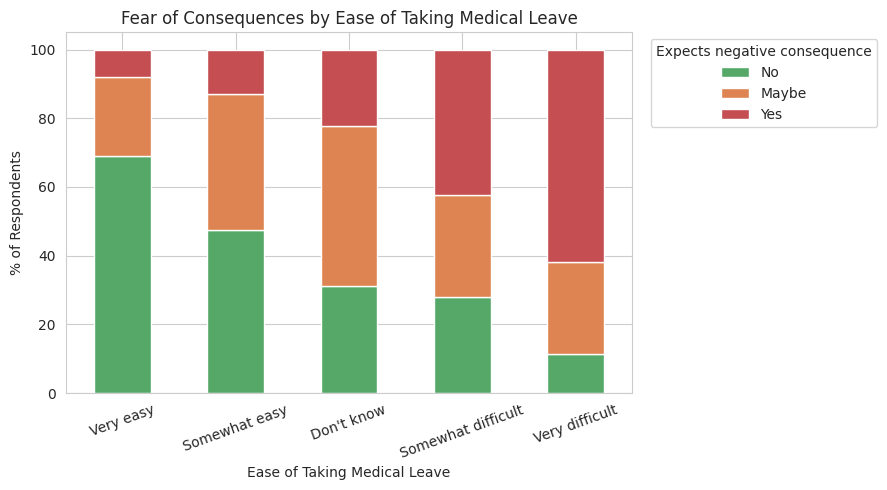

In [44]:
plt.figure(figsize=(9, 5))
leave_order = ['Very easy', 'Somewhat easy', "Don't know", 'Somewhat difficult', 'Very difficult']
ct = pd.crosstab(df['leave'], df['mental_health_consequence'], normalize='index').reindex(leave_order) * 100
ct = ct[['No', 'Maybe', 'Yes']]
ct.plot(kind='bar', stacked=True, color=['#55A868', '#DD8452', '#C44E52'], ax=plt.gca())
plt.title('Fear of Consequences by Ease of Taking Medical Leave')
plt.xlabel('Ease of Taking Medical Leave')
plt.ylabel('% of Respondents')
plt.legend(title='Expects negative consequence', bbox_to_anchor=(1.02, 1), loc='upper left')
plt.xticks(rotation=20)
plt.tight_layout()
plt.show()

**Why did you pick the specific chart?**
Same stacked, normalized bar chart approach as Chart 11 — showing how the full distribution of consequence-fear shifts as leave gets progressively harder to take.

**What is/are the insight(s) found from the chart?**
Fear of negative consequences rises steadily as medical leave becomes harder to take — from 8% "Yes" when leave is very easy, up to 62% "Yes" when it's very difficult. There's also a real wrinkle: respondents who don't know how easy leave is show the highest uncertainty of any group (47% answer "Maybe" to the consequence question), higher even than the "Somewhat difficult" group. Not knowing your leave policy appears to breed anxiety on its own, independent of what the policy actually says.

**Will the gained insights help creating a positive business impact? Are there any insights that lead to negative growth? Justify with specific reason.**
This adds a second angle to Chart 8's finding — it's not just benefits and care options that need clear communication, leave policy does too. The "Don't know" group's high uncertainty suggests that simply making leave policy clear and easy to find, even without changing the policy itself, could reduce the ambient fear that's suppressing disclosure elsewhere in the dataset.

**Chart 18: Mental Health vs Physical Health — Perceived Parity**

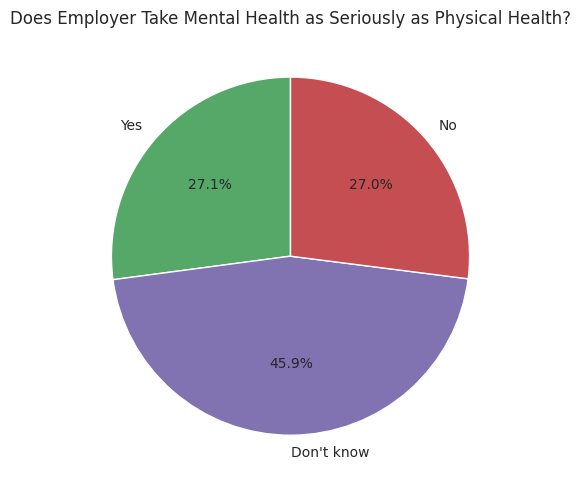

In [45]:
plt.figure(figsize=(8, 5))
mvp_counts = df['mental_vs_physical'].value_counts().reindex(['Yes', "Don't know", 'No'])
colors = ['#55A868', '#8172B2', '#C44E52']
plt.pie(mvp_counts.values, labels=mvp_counts.index, autopct='%1.1f%%',
        colors=colors, startangle=90)
plt.title('Does Employer Take Mental Health as Seriously as Physical Health?')
plt.tight_layout()
plt.show()

**Why did you pick the specific chart?**
A pie chart works well as the closing chart of this section since it's a single three-way proportion, and it echoes the format of Chart 4, giving the visualization section a sense of bookending the treatment question it opened with.

**What is/are the insight(s) found from the chart?**
Only 27% of respondents believe their employer takes mental health as seriously as physical health, and just as many (27%) explicitly say no. But the largest group by far — 46% — simply doesn't know. Uncertainty, not disagreement, is the dominant response to this question.

**Will the gained insights help creating a positive business impact? Are there any insights that lead to negative growth? Justify with specific reason.**
This closing chart ties the whole section together: the recurring theme across benefits, care options, leave policy, and now parity itself isn't that employers are necessarily bad on mental health — it's that most employees simply don't know where they stand. That reframes the entire business objective's answer: the highest-leverage, lowest-cost fix available across nearly every chart in this notebook is communication and transparency, not necessarily new policy.

## **5. Solution to Business Objective**

**What do you suggest the client to achieve Business Objective?**

- Improve internal communication of existing mental health benefits, care options, and leave policy — employees who don't know what's available underperform even employees who know the answer is "no"
- Train supervisors on receiving mental health disclosures, since fear of consequences (not policy itself) is what suppresses conversations
- Target awareness campaigns at early-career employees and those without a known family history, the two groups seeking treatment at the lowest rates
- Company size and remote-work status showed no meaningful relationship with treatment-seeking, so restructuring around either isn't a priority for this objective

# **Conclusion**

This analysis worked through 1,259 responses from the 2014 OSMI Mental Health in Tech Survey, cleaned down to 1,251 after removing invalid age entries, to understand what drives mental health treatment-seeking among tech employees and how well employers support it.

Treatment-seeking sits close to 50/50 across the whole sample, but that average hides real variation. Family history, awareness of employer care options, and age are the strongest individual predictors of whether someone seeks treatment. Structural factors like company size, remote-work status, and even working at a tech company specifically showed almost no relationship with treatment-seeking — the meaningful drivers are cultural and informational, not organizational.

The strongest recurring theme across the notebook is that uncertainty, not outright refusal, is the biggest gap. More respondents don't know whether their employer offers care options, protects anonymity, or takes mental health seriously than actively say no to any of those. That gap between "has support" and "employees know they have support" is the clearest opportunity this dataset points to.